# SOMSC scenario and location exploratory analysis

This notebook loads the same DayCent raw data used by the yearly SOMSC workflow, then builds analysis panels for soil organic carbon stock (`somsc`). The main goal is to understand why SOMSC is hard for the LSTM: how much it moves across years, whether that movement is location specific, how strong the management scenario signal is, and which points are unusually responsive or flat.

The first run can be slow because it reads the raw CSV files. After that, the notebook reuses cached pickle files under `daycent/data/analysis_cache/`.

Run this with the `wstatt` conda environment or a Jupyter kernel backed by that environment.

## Setup

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
except Exception:
    sns = None
    plt.style.use('ggplot')

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'daycent' / 'lib').exists():
            return candidate
    raise RuntimeError(f'Could not find daycent/lib from {start}')

REPO_ROOT = find_repo_root()
DAYCENT_LIB = REPO_ROOT / 'daycent' / 'lib'
if str(DAYCENT_LIB) not in sys.path:
    sys.path.insert(0, str(DAYCENT_LIB))

from utils.config import ExperimentConfig
from data.preprocessing import load_raw_data
from data.yearly import aggregate_management_monthly, aggregate_weather_monthly

print(f'Repo root: {REPO_ROOT}')
print(f'DayCent lib: {DAYCENT_LIB}')

Repo root: /projects/standard/kumarv/shared/dwij
DayCent lib: /projects/standard/kumarv/shared/dwij/daycent/lib


In [2]:
# Change this path if you want to analyze a different split/config.
CONFIG_PATH = DAYCENT_LIB / 'configs' / 'yearly' / 'experiment1.yaml'

# December is what train_yearly_somsc.py predicts. You can set this to another month for monthly checks.
ANALYSIS_MONTH = 12

# Keep True after the first run. Delete the cache directory if the raw data changes.
USE_CACHE = True

config = ExperimentConfig.from_yaml(str(CONFIG_PATH))
CACHE_DIR = REPO_ROOT / 'daycent' / 'data' / 'analysis_cache' / config.experiment_id
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Config: {CONFIG_PATH}')
print(f'Experiment: {config.experiment_id}')
print(f'Cache: {CACHE_DIR}')
print(f'Scenarios loaded by config: {config.data.get_all_scenario_ids()}')
print(f'Number of configured points: {len(config.data.get_all_point_ids())}')

Config: /projects/standard/kumarv/shared/dwij/daycent/lib/configs/yearly/experiment1.yaml
Experiment: yearly_december_somsc_v1
Cache: /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1
Scenarios loaded by config: ['1', '10', '11', '12', '13', '2', '3', '4', '5', '6', '7', '8', '9']
Number of configured points: 200


## Load and cache analysis-ready frames

This uses `load_raw_data`, `aggregate_weather_monthly`, and `aggregate_management_monthly`, matching the loading path in `daycent/lib/data/yearly.py`. SOMSC stays in original DayCent units here; it is not normalized.

In [3]:
def _read_pickle(path):
    return pd.read_pickle(path)

def _write_pickle(df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_pickle(path)

def _standardize_ids(df):
    df = df.copy()
    for col in ['scenario_id', 'point_id', 'id']:
        if col in df.columns:
            df[col] = df[col].astype(str)
    if 'Year' in df.columns:
        df['Year'] = df['Year'].astype(int)
    if 'month' in df.columns:
        df['month'] = df['month'].astype(int)
    return df

def load_analysis_frames(config, cache_dir, use_cache=True):
    paths = {
        'soc_monthly': cache_dir / 'soc_monthly.pkl',
        'yield_annual': cache_dir / 'yield_annual.pkl',
        'weather_monthly': cache_dir / 'weather_monthly.pkl',
        'management_monthly': cache_dir / 'management_monthly.pkl',
    }
    if use_cache and all(path.exists() for path in paths.values()):
        print('Loading cached analysis frames')
        return {name: _read_pickle(path) for name, path in paths.items()}

    raw_data = load_raw_data(config)

    output = _standardize_ids(raw_data['output_df'])
    soc_cols = [col for col in ['scenario_id', 'point_id', 'Year', 'month', 'somsc'] if col in output.columns]
    soc_monthly = output.loc[output['somsc'].notna(), soc_cols].copy()
    soc_monthly = (
        soc_monthly.groupby(['scenario_id', 'point_id', 'Year', 'month'], as_index=False)['somsc']
        .mean()
        .sort_values(['scenario_id', 'point_id', 'Year', 'month'])
        .reset_index(drop=True)
    )

    if 'cgrain' in output.columns:
        yield_annual = output.loc[output['cgrain'].notna(), ['scenario_id', 'point_id', 'Year', 'cgrain']].copy()
        yield_annual = (
            yield_annual.groupby(['scenario_id', 'point_id', 'Year'], as_index=False)['cgrain']
            .first()
            .sort_values(['scenario_id', 'point_id', 'Year'])
            .reset_index(drop=True)
        )
    else:
        yield_annual = pd.DataFrame(columns=['scenario_id', 'point_id', 'Year', 'cgrain'])

    weather_monthly = _standardize_ids(aggregate_weather_monthly(raw_data['weather_df']))
    management_monthly = _standardize_ids(aggregate_management_monthly(raw_data['management_df']))

    frames = {
        'soc_monthly': soc_monthly,
        'yield_annual': yield_annual,
        'weather_monthly': weather_monthly,
        'management_monthly': management_monthly,
    }
    for name, df in frames.items():
        _write_pickle(df, paths[name])
        print(f'Cached {name}: {df.shape} -> {paths[name]}')
    return frames

frames = load_analysis_frames(config, CACHE_DIR, use_cache=USE_CACHE)
soc_monthly = frames['soc_monthly']
yield_annual = frames['yield_annual']
weather_monthly = frames['weather_monthly']
management_monthly = frames['management_monthly']

for name, df in frames.items():
    print(f'{name:20s} {df.shape}')


LOADING RAW DATA: yearly_december_somsc_v1

Loading 13 unique scenarios, 200 points...

1. Loading weather data...
   Weather data shape: (1826400, 6)

2. Loading management data...
   Management data shape: (633387, 18)

3. Loading output data for 13 scenarios...


Loading scenarios: 100%|██████████| 13/13 [01:39<00:00,  7.67s/it]


   Output data shape: (803019, 17)

RAW DATA LOAD COMPLETE

Cached soc_monthly: (748800, 5) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/soc_monthly.pkl
Cached yield_annual: (54219, 4) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/yield_annual.pkl
Cached weather_monthly: (60000, 6) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/weather_monthly.pkl
Cached management_monthly: (314389, 18) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/management_monthly.pkl
soc_monthly          (748800, 5)
yield_annual         (54219, 4)
weather_monthly      (60000, 6)
management_monthly   (314389, 18)


In [4]:
def split_grid(config):
    rows = []
    split_getters = [
        ('train', config.data.get_train_config),
        ('val', config.data.get_val_config),
        ('test', config.data.get_test_config),
    ]
    for split_name, getter in split_getters:
        split = getter()
        if not split:
            continue
        idx = pd.MultiIndex.from_product(
            [[str(s) for s in split['scenarios']], [str(p) for p in split['points']], [int(y) for y in split['years']]],
            names=['scenario_id', 'point_id', 'Year'],
        )
        part = idx.to_frame(index=False)
        part['split'] = split_name
        rows.append(part)
    if not rows:
        return pd.DataFrame(columns=['scenario_id', 'point_id', 'Year', 'split'])
    return pd.concat(rows, ignore_index=True).drop_duplicates(['scenario_id', 'point_id', 'Year'])

split_df = split_grid(config)
print(f'Split grid rows: {len(split_df):,}')
display(split_df['split'].value_counts().to_frame('configured_rows'))

Split grid rows: 16,560


,configured_rows
split,
train,13680
val,1680
test,1200


## Build December SOMSC panel and yearly movement

In [5]:
soc_dec = soc_monthly.loc[soc_monthly['month'].eq(ANALYSIS_MONTH)].copy()
soc_dec = (
    soc_dec.groupby(['scenario_id', 'point_id', 'Year'], as_index=False)['somsc']
    .mean()
    .sort_values(['scenario_id', 'point_id', 'Year'])
    .reset_index(drop=True)
)
soc_dec = soc_dec.merge(split_df, on=['scenario_id', 'point_id', 'Year'], how='left')
soc_dec['split'] = soc_dec['split'].fillna('loaded_extra')
soc_dec['prev_somsc'] = soc_dec.groupby(['scenario_id', 'point_id'])['somsc'].shift(1)
soc_dec['delta'] = soc_dec['somsc'] - soc_dec['prev_somsc']
soc_dec['abs_delta'] = soc_dec['delta'].abs()
soc_dec['relative_delta_pct'] = np.where(soc_dec['prev_somsc'].abs() > 0, 100.0 * soc_dec['delta'] / soc_dec['prev_somsc'], np.nan)

print(f'December SOMSC rows: {len(soc_dec):,}')
print(f'Scenarios: {soc_dec.scenario_id.nunique():,} | points: {soc_dec.point_id.nunique():,} | years: {soc_dec.Year.min()}-{soc_dec.Year.max()}')
display(soc_dec.head())
display(soc_dec[['somsc', 'delta', 'abs_delta', 'relative_delta_pct']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

December SOMSC rows: 62,400
Scenarios: 13 | points: 200 | years: 2000-2023


,scenario_id,point_id,Year,somsc,split,prev_somsc,delta,abs_delta,relative_delta_pct
0,1,1699811,2000,4444.80,loaded_extra,NaN,NaN,NaN,NaN
1,1,1699811,2001,4218.18,loaded_extra,4444.80,-226.62,226.62,-5.098542
2,1,1699811,2002,4020.73,loaded_extra,4218.18,-197.45,197.45,-4.680929
3,1,1699811,2003,3843.46,loaded_extra,4020.73,-177.27,177.27,-4.408901
4,1,1699811,2004,3763.82,loaded_extra,3843.46,-79.64,79.64,-2.072091


,count,mean,std,min,1%,5%,50%,95%,99%,max
somsc,62400.0,5217.703735,1213.783726,1256.280000,1974.4199,2866.572500,5378.930000,6975.550500,7471.322100,8145.170000
delta,59800.0,-14.958658,67.451306,-320.490000,-194.1610,-145.760500,-1.480000,75.030500,113.020100,256.840000
abs_delta,59800.0,52.475977,44.940734,0.000000,0.6300,3.230000,40.600000,148.021500,196.320400,320.490000
relative_delta_pct,59800.0,-0.314979,1.328876,-6.118292,-3.9563,-2.807778,-0.029005,1.429467,2.121705,4.491511


In [6]:
trajectory_rows = []
for (scenario_id, point_id), group in soc_dec.groupby(['scenario_id', 'point_id']):
    g = group.sort_values('Year').dropna(subset=['somsc'])
    if len(g) < 2:
        continue
    first = g.iloc[0]
    last = g.iloc[-1]
    deltas = g['delta'].dropna()
    trajectory_rows.append({
        'scenario_id': scenario_id,
        'point_id': point_id,
        'first_year': int(first['Year']),
        'last_year': int(last['Year']),
        'n_years': int(g['Year'].nunique()),
        'start_somsc': float(first['somsc']),
        'end_somsc': float(last['somsc']),
        'total_change': float(last['somsc'] - first['somsc']),
        'annualized_change': float((last['somsc'] - first['somsc']) / max(1, int(last['Year'] - first['Year']))),
        'mean_abs_delta': float(deltas.abs().mean()) if len(deltas) else np.nan,
        'delta_std': float(deltas.std()) if len(deltas) > 1 else np.nan,
        'max_abs_delta': float(deltas.abs().max()) if len(deltas) else np.nan,
    })

trajectory = pd.DataFrame(trajectory_rows)
trajectory['abs_total_change'] = trajectory['total_change'].abs()

scenario_summary = (
    trajectory.groupby('scenario_id')
    .agg(
        n_point_trajectories=('point_id', 'nunique'),
        mean_total_change=('total_change', 'mean'),
        median_total_change=('total_change', 'median'),
        mean_abs_total_change=('abs_total_change', 'mean'),
        mean_abs_annual_change=('annualized_change', lambda x: x.abs().mean()),
        mean_abs_delta=('mean_abs_delta', 'mean'),
    )
    .sort_values('mean_abs_total_change', ascending=False)
)

print('Largest scenario-point multi-year movement')
display(trajectory.sort_values('abs_total_change', ascending=False).head(20))
print('Scenario-level movement summary')
display(scenario_summary)

Largest scenario-point multi-year movement


,scenario_id,point_id,first_year,last_year,n_years,start_somsc,end_somsc,total_change,annualized_change,mean_abs_delta,delta_std,max_abs_delta,abs_total_change
633,12,1723798,2000,2023,24,7588.33,5276.47,-2311.86,-100.515652,102.066087,86.707614,277.48,2311.86
601,12,1707438,2000,2023,24,5207.50,3174.76,-2032.74,-88.380000,89.425217,73.270170,246.33,2032.74
33,1,1723798,2000,2023,24,7588.33,5559.38,-2028.95,-88.215217,95.777826,91.115808,285.49,2028.95
608,12,1719165,2000,2023,24,5210.81,3191.10,-2019.71,-87.813478,89.221304,73.837028,246.89,2019.71
629,12,1723142,2000,2023,24,7416.71,5399.20,-2017.51,-87.717826,91.290000,77.745290,235.38,2017.51
605,12,1718554,2000,2023,24,7316.77,5310.70,-2006.07,-87.220435,90.700435,77.974997,238.36,2006.07
617,12,1720288,2000,2023,24,7450.28,5452.55,-1997.73,-86.857826,89.464783,76.936955,238.99,1997.73
833,13,1723798,2000,2023,24,7680.44,5686.88,-1993.56,-86.676522,100.933043,101.656761,246.97,1993.56
795,12,979168,2000,2023,24,5974.73,4052.20,-1922.53,-83.588261,86.330870,70.047923,233.96,1922.53
627,12,1722641,2000,2023,24,4950.86,3029.77,-1921.09,-83.525652,84.754348,71.165696,235.88,1921.09


Scenario-level movement summary


,n_point_trajectories,mean_total_change,median_total_change,mean_abs_total_change,mean_abs_annual_change,mean_abs_delta
scenario_id,,,,,,
1,200,-879.76020,-728.365,879.76020,38.250443,60.935987
12,200,-795.97580,-560.815,795.97580,34.607643,46.149952
13,200,-647.72340,-462.835,647.72340,28.161887,73.724670
9,200,-633.87395,-461.975,633.87395,27.559737,52.700420
11,200,-534.05250,-317.400,534.05250,23.219674,64.154930
5,200,-492.95480,-381.725,492.95480,21.432817,42.470709
8,200,247.64430,436.445,464.81350,20.209283,67.574852
4,200,-452.66465,-262.225,452.66465,19.681072,48.911589
3,200,298.49215,463.800,445.19605,19.356350,42.050672


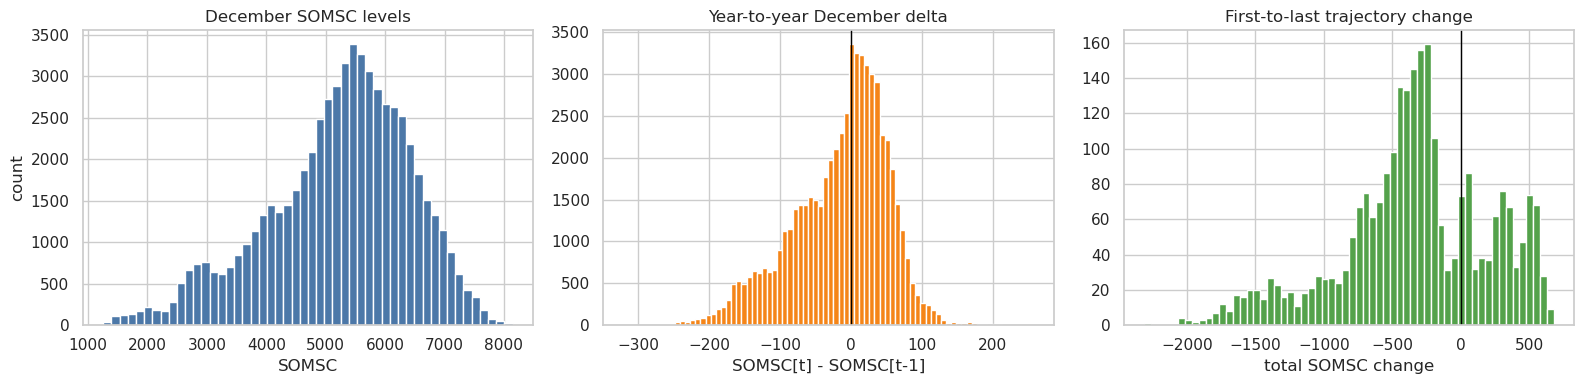

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(soc_dec['somsc'].dropna(), bins=50, color='#4c78a8')
axes[0].set_title('December SOMSC levels')
axes[0].set_xlabel('SOMSC')
axes[0].set_ylabel('count')

axes[1].hist(soc_dec['delta'].dropna(), bins=80, color='#f58518')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Year-to-year December delta')
axes[1].set_xlabel('SOMSC[t] - SOMSC[t-1]')

axes[2].hist(trajectory['total_change'].dropna(), bins=60, color='#54a24b')
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title('First-to-last trajectory change')
axes[2].set_xlabel('total SOMSC change')

plt.tight_layout()

## Scenario dependence and point elasticity

`mean_scenario_spread` is the average within-point, within-year range across scenarios. `scenario_to_temporal_ratio` compares that scenario spread to the average year-to-year movement at the same point.

In [8]:
scenario_spread = (
    soc_dec.groupby(['point_id', 'Year'])
    .agg(
        n_scenarios=('scenario_id', 'nunique'),
        scenario_min=('somsc', 'min'),
        scenario_max=('somsc', 'max'),
        scenario_std=('somsc', 'std'),
        scenario_mean=('somsc', 'mean'),
    )
    .reset_index()
)
scenario_spread['scenario_spread'] = scenario_spread['scenario_max'] - scenario_spread['scenario_min']
scenario_spread = scenario_spread.loc[scenario_spread['n_scenarios'] >= 2].copy()

point_temporal = (
    soc_dec.dropna(subset=['delta'])
    .groupby('point_id')
    .agg(
        mean_abs_delta=('abs_delta', 'mean'),
        median_abs_delta=('abs_delta', 'median'),
        max_abs_delta=('abs_delta', 'max'),
        delta_std=('delta', 'std'),
        n_delta_rows=('delta', 'size'),
    )
)

point_sensitivity = (
    scenario_spread.groupby('point_id')
    .agg(
        mean_scenario_spread=('scenario_spread', 'mean'),
        median_scenario_spread=('scenario_spread', 'median'),
        max_scenario_spread=('scenario_spread', 'max'),
        mean_scenario_std=('scenario_std', 'mean'),
        n_scenario_years=('scenario_spread', 'size'),
    )
    .join(point_temporal, how='left')
    .reset_index()
)
point_sensitivity['scenario_to_temporal_ratio'] = point_sensitivity['mean_scenario_spread'] / (point_sensitivity['mean_abs_delta'] + 1e-9)

print('Most scenario-sensitive points')
display(point_sensitivity.sort_values('mean_scenario_spread', ascending=False).head(20))
print('Least scenario-sensitive points with enough scenario-year observations')
display(point_sensitivity.loc[point_sensitivity['n_scenario_years'] >= 5].sort_values('mean_scenario_spread').head(20))
print('Points where scenario spread is large relative to year-to-year movement')
display(point_sensitivity.replace([np.inf, -np.inf], np.nan).dropna(subset=['scenario_to_temporal_ratio']).sort_values('scenario_to_temporal_ratio', ascending=False).head(20))

Most scenario-sensitive points


,point_id,mean_scenario_spread,median_scenario_spread,max_scenario_spread,mean_scenario_std,n_scenario_years,mean_abs_delta,median_abs_delta,max_abs_delta,delta_std,n_delta_rows,scenario_to_temporal_ratio
33,1723798,1261.256667,1356.350,1857.70,411.854049,24,79.644582,54.48,320.49,89.445483,299,15.836064
11,1719633,1200.229583,1261.650,1794.83,392.538368,24,68.606355,46.68,269.83,84.145127,299,17.494438
17,1720288,1200.115000,1258.675,1835.99,390.909733,24,70.654582,47.37,280.71,84.058041,299,16.985664
29,1723142,1193.608750,1292.880,1820.95,390.995405,24,70.485920,47.28,273.12,83.185100,299,16.934003
5,1718554,1190.381667,1277.960,1812.70,389.763032,24,70.142742,47.78,278.97,83.050825,299,16.970846
18,1720409,1109.847500,1172.535,1637.10,361.687374,24,63.216154,44.02,252.81,77.926525,299,17.556391
26,1722383,1068.507083,1146.410,1592.61,349.866904,24,63.450401,41.58,254.19,75.484084,299,16.840037
1,1707438,1067.126250,1111.360,1543.68,344.124346,24,67.258896,40.54,269.18,72.408141,299,15.865949
35,1724370,1063.834167,1150.330,1595.59,348.179860,24,63.517458,42.29,250.10,75.098785,299,16.748689
8,1719165,1063.761250,1115.625,1546.00,343.550271,24,67.290067,42.89,270.66,72.617505,299,15.808593


Least scenario-sensitive points with enough scenario-year observations


,point_id,mean_scenario_spread,median_scenario_spread,max_scenario_spread,mean_scenario_std,n_scenario_years,mean_abs_delta,median_abs_delta,max_abs_delta,delta_std,n_delta_rows,scenario_to_temporal_ratio
143,712790,369.042500,393.665,591.16,114.125523,24,22.300970,18.03,80.16,27.559182,299,16.548271
62,1784465,421.507083,437.845,714.22,131.012297,24,26.940635,22.57,90.38,33.337915,299,15.645774
145,714939,449.524583,473.695,681.94,142.641873,24,28.537893,21.51,108.90,34.589008,299,15.751849
144,712888,513.611250,539.120,850.42,157.235377,24,31.911338,27.48,115.07,39.811997,299,16.094946
65,1795098,522.120000,547.195,894.83,162.240647,24,33.703712,28.90,113.86,41.655558,299,15.491469
142,711727,523.930000,543.615,843.14,165.123639,24,32.766187,27.55,115.19,41.200984,299,15.989959
54,1744248,530.408333,572.245,833.96,172.294315,24,31.967358,25.58,122.94,39.949894,299,16.592186
137,705042,537.768750,563.985,877.24,167.784991,24,33.288027,28.87,118.65,41.872970,299,16.155020
21,1721074,543.056667,581.195,885.25,169.375289,24,31.545753,26.86,109.65,38.999376,299,17.214890
4,1718547,547.920417,583.175,898.93,171.545411,24,31.772274,26.85,109.78,39.294987,299,17.245238


Points where scenario spread is large relative to year-to-year movement


,point_id,mean_scenario_spread,median_scenario_spread,max_scenario_spread,mean_scenario_std,n_scenario_years,mean_abs_delta,median_abs_delta,max_abs_delta,delta_std,n_delta_rows,scenario_to_temporal_ratio
50,1739762,964.456667,1070.770,1444.14,309.133287,24,52.314749,41.18,189.56,66.487567,299,18.435655
42,1733863,997.716250,1102.995,1486.42,320.768258,24,54.705217,41.60,202.05,69.784683,299,18.238046
40,1730738,986.195000,1096.010,1467.52,313.922558,24,54.439732,40.22,200.71,69.415913,299,18.115354
53,1742815,942.797083,1043.250,1419.74,301.575664,24,52.058161,40.79,186.40,65.826090,299,18.110457
55,1744477,977.972500,1082.050,1476.22,313.629998,24,54.357993,41.25,202.09,69.223409,299,17.991328
51,1740351,900.232500,993.800,1363.90,285.568397,24,50.294047,38.94,185.05,64.024565,299,17.899385
47,1737078,979.897083,1080.685,1480.98,314.862784,24,54.771639,41.97,201.38,69.694407,299,17.890593
37,1725306,973.217083,1074.620,1472.96,312.451845,24,54.505652,40.33,199.68,69.375344,299,17.855342
38,1729582,838.820000,926.865,1263.70,267.506443,24,47.298796,36.22,175.50,60.113812,299,17.734489
12,1719717,696.114583,739.440,1089.82,221.905496,24,39.278729,30.19,141.33,49.633809,299,17.722431


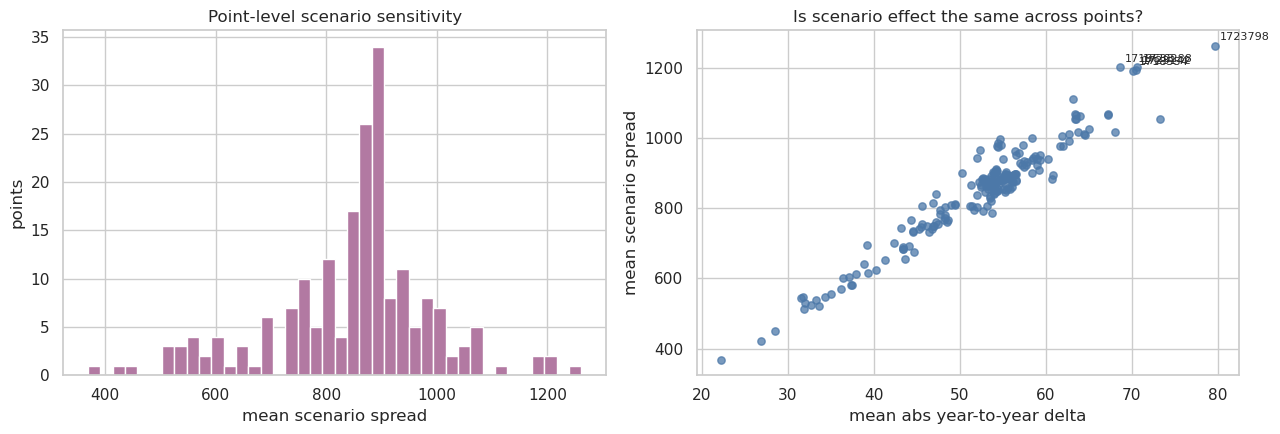

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(point_sensitivity['mean_scenario_spread'].dropna(), bins=40, color='#b279a2')
axes[0].set_title('Point-level scenario sensitivity')
axes[0].set_xlabel('mean scenario spread')
axes[0].set_ylabel('points')

plot_df = point_sensitivity.dropna(subset=['mean_abs_delta', 'mean_scenario_spread'])
axes[1].scatter(plot_df['mean_abs_delta'], plot_df['mean_scenario_spread'], s=28, alpha=0.75, color='#4c78a8')
axes[1].set_title('Is scenario effect the same across points?')
axes[1].set_xlabel('mean abs year-to-year delta')
axes[1].set_ylabel('mean scenario spread')

for _, row in plot_df.sort_values('mean_scenario_spread', ascending=False).head(5).iterrows():
    axes[1].annotate(row['point_id'], (row['mean_abs_delta'], row['mean_scenario_spread']), fontsize=8, xytext=(4, 4), textcoords='offset points')

plt.tight_layout()

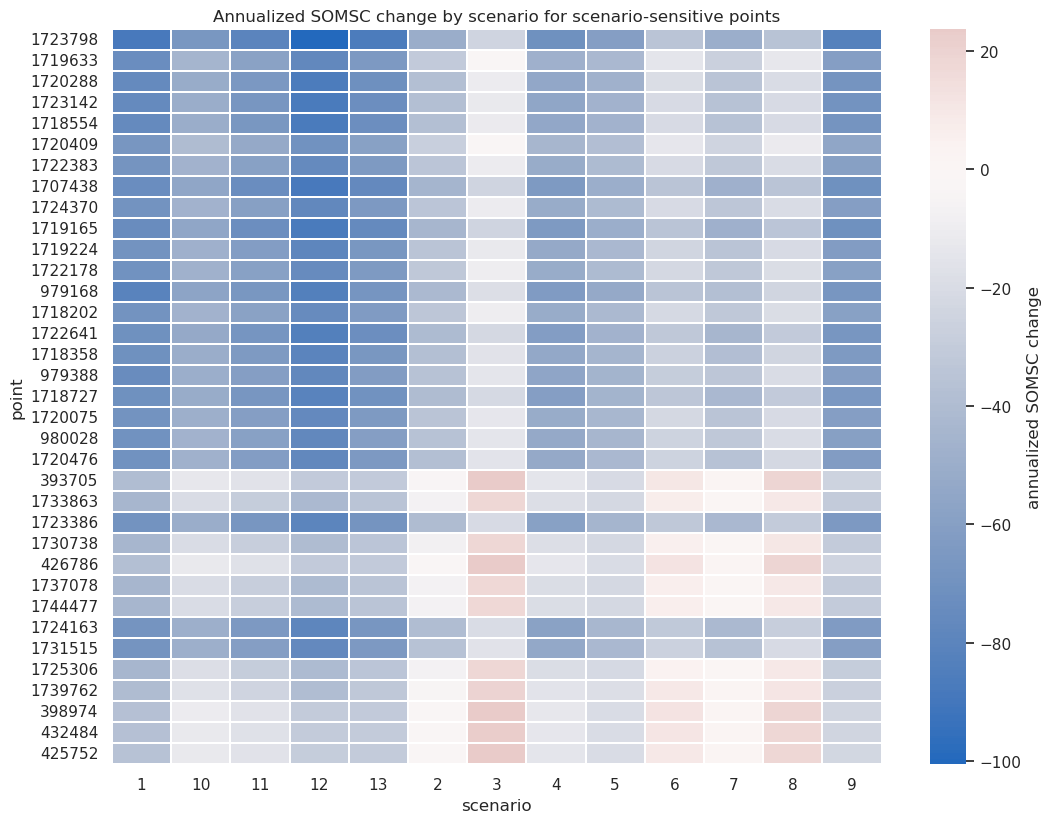

In [10]:
top_heatmap_points = point_sensitivity.sort_values('mean_scenario_spread', ascending=False).head(35)['point_id']
heat = (
    trajectory.loc[trajectory['point_id'].isin(top_heatmap_points)]
    .pivot_table(index='point_id', columns='scenario_id', values='annualized_change', aggfunc='mean')
    .loc[top_heatmap_points]
)

plt.figure(figsize=(11, max(5, 0.24 * len(heat))))
if sns is not None:
    sns.heatmap(heat, cmap='vlag', center=0, linewidths=0.2, cbar_kws={'label': 'annualized SOMSC change'})
else:
    plt.imshow(heat, aspect='auto', cmap='coolwarm')
    plt.colorbar(label='annualized SOMSC change')
    plt.xticks(range(len(heat.columns)), heat.columns)
    plt.yticks(range(len(heat.index)), heat.index)
plt.title('Annualized SOMSC change by scenario for scenario-sensitive points')
plt.xlabel('scenario')
plt.ylabel('point')
plt.tight_layout()

## Interesting points to inspect directly

In [11]:
point_trend = (
    trajectory.groupby('point_id')
    .agg(
        mean_total_change=('total_change', 'mean'),
        mean_abs_total_change=('abs_total_change', 'mean'),
        min_total_change=('total_change', 'min'),
        max_total_change=('total_change', 'max'),
        mean_annualized_change=('annualized_change', 'mean'),
    )
    .reset_index()
)
point_rank = point_sensitivity.merge(point_trend, on='point_id', how='left')

def collect_points(label, df, sort_col, ascending=False, n=3):
    cols = ['point_id', sort_col]
    out = df.dropna(subset=[sort_col]).sort_values(sort_col, ascending=ascending).head(n)[cols].copy()
    out['reason'] = label
    out = out.rename(columns={sort_col: 'reason_value'})
    return out[['reason', 'point_id', 'reason_value']]

interesting = pd.concat([
    collect_points('high_scenario_spread', point_rank, 'mean_scenario_spread', ascending=False, n=3),
    collect_points('low_scenario_spread', point_rank.loc[point_rank['n_scenario_years'] >= 5], 'mean_scenario_spread', ascending=True, n=3),
    collect_points('high_year_to_year_delta', point_rank, 'mean_abs_delta', ascending=False, n=3),
    collect_points('scenario_dominated', point_rank.replace([np.inf, -np.inf], np.nan), 'scenario_to_temporal_ratio', ascending=False, n=3),
    collect_points('largest_mean_loss', point_rank, 'mean_total_change', ascending=True, n=2),
    collect_points('largest_mean_gain', point_rank, 'mean_total_change', ascending=False, n=2),
], ignore_index=True)
selected_points = interesting.drop_duplicates('point_id')['point_id'].tolist()

display(interesting)
print(f'Selected points: {selected_points}')

,reason,point_id,reason_value
0,high_scenario_spread,1723798,1261.256667
1,high_scenario_spread,1719633,1200.229583
2,high_scenario_spread,1720288,1200.115000
3,low_scenario_spread,712790,369.042500
4,low_scenario_spread,1784465,421.507083
5,low_scenario_spread,714939,449.524583
6,high_year_to_year_delta,1723798,79.644582
7,high_year_to_year_delta,979168,73.337659
8,high_year_to_year_delta,1720288,70.654582
9,scenario_dominated,1739762,18.435655


Selected points: ['1723798', '1719633', '1720288', '712790', '1784465', '714939', '979168', '1739762', '1733863', '1730738', '1707438', '772249', '789644']


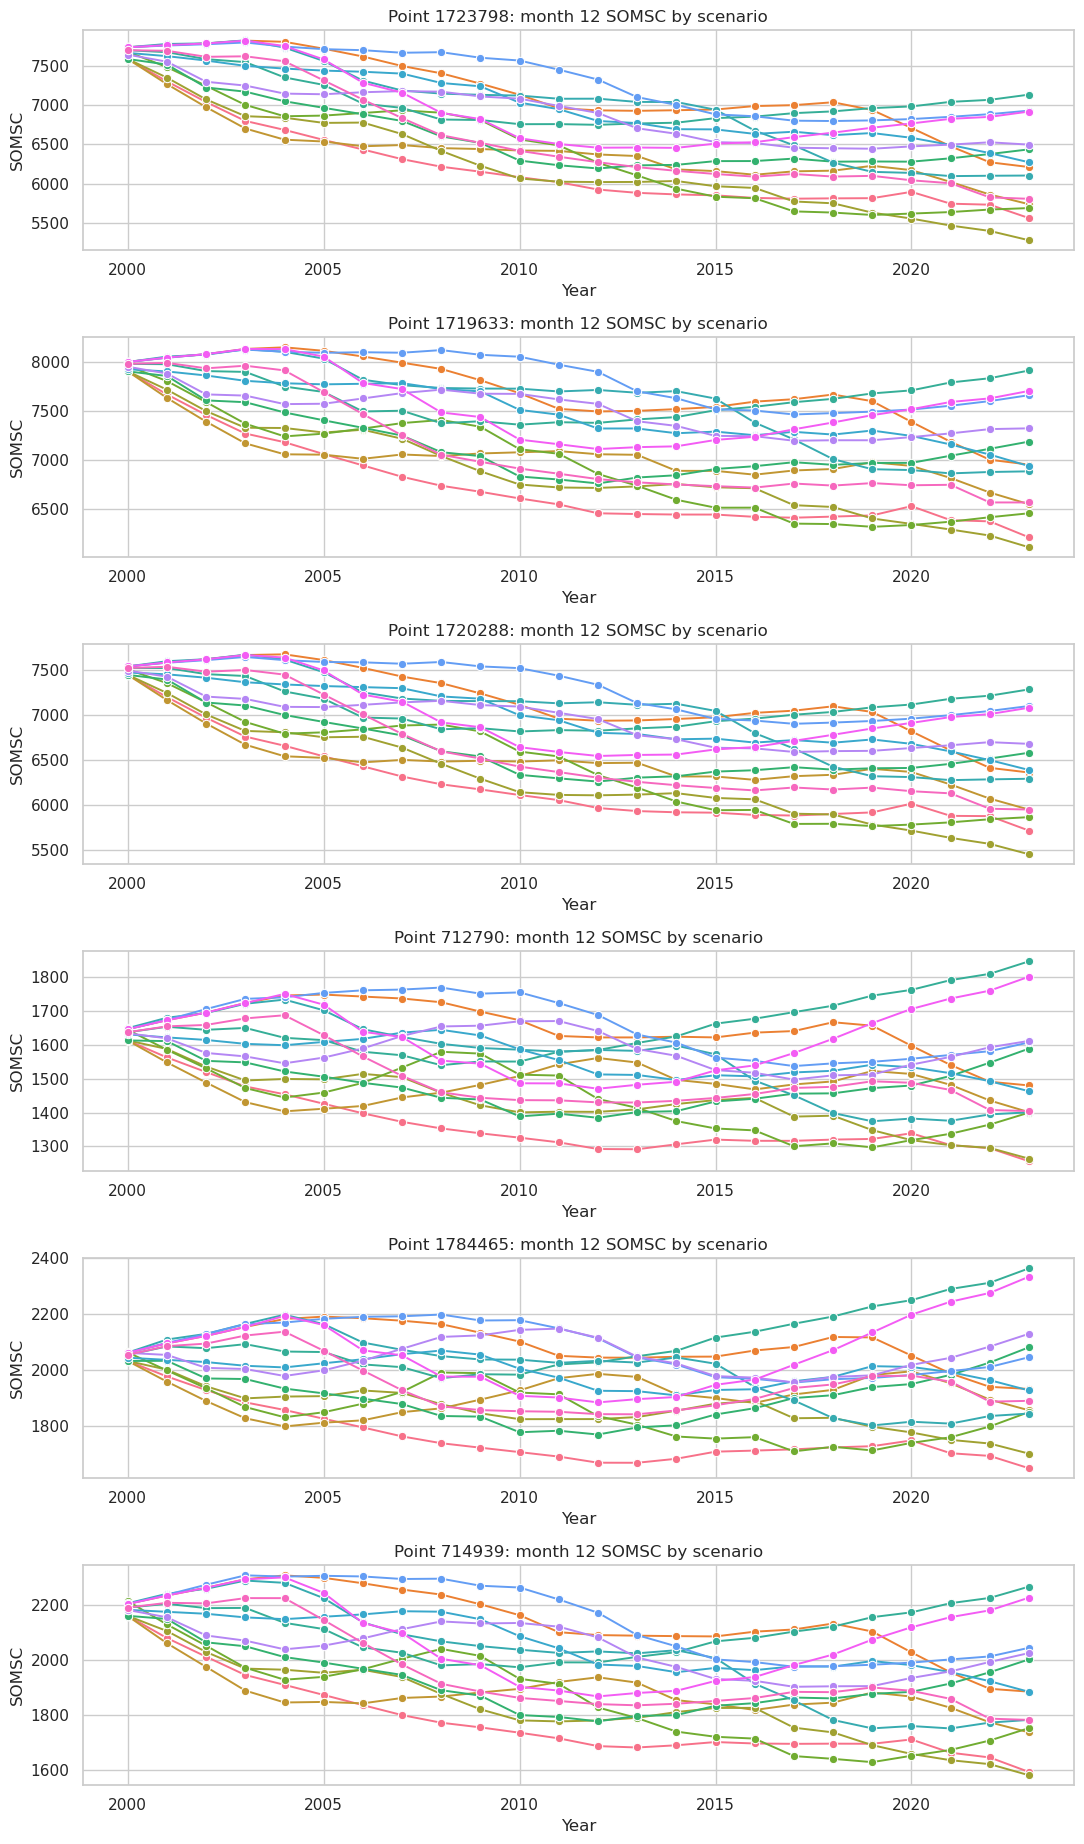

In [12]:
def plot_point_scenarios(point_id, month=12, max_scenarios=16, ax=None):
    data = soc_monthly.loc[(soc_monthly['point_id'].eq(str(point_id))) & (soc_monthly['month'].eq(month))].copy()
    if data.empty:
        if ax is not None:
            ax.set_title(f'{point_id}: no data')
        return ax
    scenario_ranges = data.groupby('scenario_id')['somsc'].agg(['min', 'max'])
    scenario_ranges['range'] = scenario_ranges['max'] - scenario_ranges['min']
    chosen = scenario_ranges.sort_values('range', ascending=False).head(max_scenarios).index
    data = data.loc[data['scenario_id'].isin(chosen)].sort_values(['scenario_id', 'Year'])
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    if sns is not None:
        sns.lineplot(data=data, x='Year', y='somsc', hue='scenario_id', marker='o', linewidth=1.4, ax=ax, legend=False)
    else:
        for scenario_id, g in data.groupby('scenario_id'):
            ax.plot(g['Year'], g['somsc'], marker='o', linewidth=1.4, label=scenario_id)
    ax.set_title(f'Point {point_id}: month {month} SOMSC by scenario')
    ax.set_xlabel('Year')
    ax.set_ylabel('SOMSC')
    return ax

n_plot = min(6, len(selected_points))
if n_plot:
    fig, axes = plt.subplots(n_plot, 1, figsize=(11, 3.1 * n_plot), sharex=False)
    axes = np.atleast_1d(axes)
    for ax, point_id in zip(axes, selected_points[:n_plot]):
        plot_point_scenarios(point_id, month=ANALYSIS_MONTH, ax=ax)
    plt.tight_layout()
else:
    print('No selected points to plot.')

## Location and initial-condition context

,point_id,mean_scenario_spread,median_scenario_spread,max_scenario_spread,mean_scenario_std,n_scenario_years,mean_abs_delta,median_abs_delta,max_abs_delta,delta_std,n_delta_rows,scenario_to_temporal_ratio,POINT_X,POINT_Y,STATE,COUNTY,county_fips,MLRARSYM,LRRSYM,elevation,gcm_wth_lat,gcm_wth_lon,weathercsv_name,init_PRECIP(1),init_PRECIP(2),init_PRECIP(3),init_PRECIP(4),init_PRECIP(5),init_PRECIP(6),init_PRECIP(7),init_PRECIP(8),init_PRECIP(9),init_PRECIP(10),init_PRECIP(11),init_PRECIP(12),init_TMN2M(1),init_TMN2M(2),init_TMN2M(3),init_TMN2M(4),init_TMN2M(5),init_TMN2M(6),init_TMN2M(7),init_TMN2M(8),init_TMN2M(9),init_TMN2M(10),init_TMN2M(11),init_TMN2M(12),init_TMX2M(1),init_TMX2M(2),init_TMX2M(3),init_TMX2M(4),init_TMX2M(5),init_TMX2M(6),init_TMX2M(7),init_TMX2M(8),init_TMX2M(9),init_TMX2M(10),init_TMX2M(11),init_TMX2M(12),init_SITLAT,...,init_SLSATC(3),init_SLPH(3),init_SLDPMX(4),init_SLBLKD(4),init_SLFLDC(4),init_SLWLTP(4),init_SLSAND(4),init_SLCLAY(4),init_SLCLIM(4),init_SLSATC(4),init_SLPH(4),init_SLDPMX(5),init_SLBLKD(5),init_SLFLDC(5),init_SLWLTP(5),init_SLSAND(5),init_SLCLAY(5),init_SLCLIM(5),init_SLSATC(5),init_SLPH(5),"init_RMETCS(1,1)","init_RMETCS(2,1)","init_RCEMET(1,1)","init_RCEMET(2,1)",init_RSTRLG(1),init_RSTRLG(2),"init_CSTG(1,1)",init_CRPSTG(1),init_MRTFR,init_AMMONI,init_NITRAT(1),init_NITRAT(2),init_NITRAT(3),init_NITRAT(4),init_NITRAT(5),init_NITRAT(6),init_NITRAT(7),init_NITRAT(8),init_NITRAT(9),init_NITRAT(10),init_NITRAT(11),init_NITRAT(12),init_NITRAT(13),init_NITRAT(14),init_NITRAT(15),init_SWCINI(1),init_SWCINI(2),init_SWCINI(3),init_SWCINI(4),init_SWCINI(5),init_SWCINI(6),init_SWCINI(7),init_SWCINI(8),init_SWCINI(9),init_SWCINI(10),init_SWCINI(11),init_SWCINI(12),init_SWCINI(13),init_SWCINI(14),init_SWCINI(15)
0,1699811,899.693750,934.935,1293.64,289.027727,24,58.424983,38.34,246.84,63.444076,299,15.399127,-89.269241,44.438181,WI,Portage County,55097,90A,K,325.12,44.375,270.625,1699811,2.5,2.5,4.4,7.6,9.6,11.4,9.7,10.5,9.6,7.2,5.3,3.7,-14.3,-12.4,-6.3,0.8,6.9,12.4,14.8,13.9,9.0,2.7,-3.7,-11.3,-4.7,-2.0,4.3,12.7,19.4,24.6,27.0,25.8,21.2,13.9,5.2,-2.6,44.4382,...,0.00065,6.7,20,1.54,0.19704,0.09288,0.66,0.11,0.083592,0.00065,6.7,30,1.51,0.18535,0.09561,0.67,0.14,0.09561,0.00042,6.2,0.201763,0.221184,39.8139,27.4879,0.005465,0.001396,89.1625,0.003402,0.298035,0.275061,0.002989,0.009772,0.047596,0.159140,0.102160,0.048732,0.026295,0.016855,0.011005,5.499950e-03,0.005500,0.042446,0.050478,9.327450e-11,0.000000e+00,0.349961,0.526559,0.886394,1.80858,1.68844,2.06249,1.83691,1.78985,1.50944,1.035380,1.11222,2.57297,3.30322,0.000081,0.000000
1,1707438,1067.126250,1111.360,1543.68,344.124346,24,67.258896,40.54,269.18,72.408141,299,15.865949,-89.062307,45.097912,WI,Langlade County,55067,90A,K,450.61,45.125,270.875,1707438,2.7,2.4,4.2,7.2,9.0,10.8,9.7,9.1,10.2,8.1,5.2,3.9,-16.7,-15.4,-9.7,-2.1,4.5,10.2,12.7,11.9,7.4,1.1,-5.2,-13.2,-6.1,-3.3,2.6,10.5,18.0,22.9,25.2,24.1,19.3,12.0,3.2,-4.1,45.0979,...,0.00083,5.5,20,1.57,0.20876,0.08182,0.53,0.08,0.073638,0.00094,5.4,30,1.57,0.20438,0.08120,0.55,0.08,0.08120,0.00095,5.4,0.205359,0.228543,39.8990,26.3045,0.005139,0.001291,68.5430,0.003355,0.279083,0.308996,0.002785,0.007315,0.053301,0.193681,0.112107,0.050208,0.030783,0.020873,0.013418,6.711910e-03,0.006712,0.041429,0.049635,5.916950e-02,7.475150e-11,0.404437,0.587200,0.886867,1.47653,1.25847,1.65038,1.62717,1.58230,1.60986,1.701970,1.33348,2.82412,3.58198,3.885720,0.000083
2,1718202,1052.772500,1132.910,1563.87,343.268207,24,63.395284,41.29,251.93,75.100067,299,16.606480,-88.466664,44.333033,WI,Outagamie County,55087,95A,K,260.77,44.375,271.625,1718202,3.0,2.8,4.7,7.7,8.9,10.8,9.3,9.5,8.5,6.8,5.5,4.0,-12.7,-11.0,-5.5,1.4,7.6,13.3,15.8,14.8,9.6,3.5,-2.8,-9.9,-3.5,-1.0,4.9,12.9,19.8,25.3,27.7,26.5,22.2,14.8,6.4,-1.2,44.3330,...,0.00052,6.7,20,1.44,0.26055,0.10091,0.30,0.14,0.090819,0.00052,6.7,30,1.46,0.24572,0.09437,0.32,0.13,0.09437,0.00057,6.7,0.215912,0.213445,41.9057,29.1898,0.004281,0.001501,179.1230,0.0070

,mean_scenario_spread,mean_abs_delta
"init_SOM2CI(2,1)",0.982691,0.972938
"init_SOM1CI(2,1)",0.799881,0.812007
"init_SOM2CI(1,1)",0.554371,0.654853
init_RSTRLG(2),-0.567057,-0.586027
"init_RMETCS(1,1)",-0.546213,-0.560288
"init_CSTG(1,1)",0.488792,0.550296
init_BGLCIS(1),0.466853,0.544185
init_BGLIVE(1),0.452574,0.536151
init_MRTFR,0.462434,0.527816
init_AGLCIS(1),0.496499,0.523486


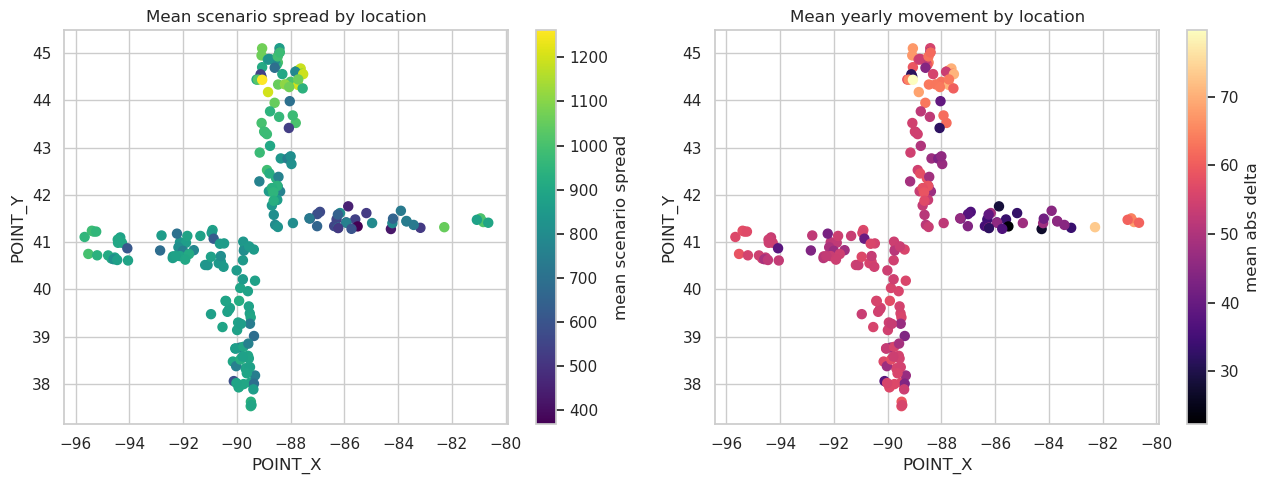

In [13]:
def read_excel_or_csv(path):
    path = Path(path)
    try:
        return pd.read_excel(path)
    except Exception:
        return pd.read_csv(path)

point_lookup = read_excel_or_csv(config.data.points_lookup)
init_cond = pd.read_excel(config.data.init_cond_file).dropna(axis=1)

if 'id' in point_lookup.columns:
    point_lookup = point_lookup.rename(columns={'id': 'point_id'})
point_lookup['point_id'] = point_lookup['point_id'].astype(str)

if 'id' in init_cond.columns:
    init_cond = init_cond.rename(columns={'id': 'point_id'})
init_cond['point_id'] = init_cond['point_id'].astype(str)
init_feature_cols = [col for col in init_cond.columns if col != 'point_id']
init_prefixed = init_cond.rename(columns={col: f'init_{col}' for col in init_feature_cols})

point_context = point_sensitivity.merge(point_lookup, on='point_id', how='left').merge(init_prefixed, on='point_id', how='left')
display(point_context.head())

coord_cols = [col for col in ['POINT_X', 'POINT_Y'] if col in point_context.columns]
if len(coord_cols) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sc0 = axes[0].scatter(point_context['POINT_X'], point_context['POINT_Y'], c=point_context['mean_scenario_spread'], s=42, cmap='viridis')
    axes[0].set_title('Mean scenario spread by location')
    axes[0].set_xlabel('POINT_X')
    axes[0].set_ylabel('POINT_Y')
    plt.colorbar(sc0, ax=axes[0], label='mean scenario spread')

    sc1 = axes[1].scatter(point_context['POINT_X'], point_context['POINT_Y'], c=point_context['mean_abs_delta'], s=42, cmap='magma')
    axes[1].set_title('Mean yearly movement by location')
    axes[1].set_xlabel('POINT_X')
    axes[1].set_ylabel('POINT_Y')
    plt.colorbar(sc1, ax=axes[1], label='mean abs delta')
    plt.tight_layout()
else:
    print('No POINT_X/POINT_Y columns found in point lookup; skipping map-style scatter.')

init_numeric = [col for col in point_context.columns if col.startswith('init_') and pd.api.types.is_numeric_dtype(point_context[col])]
if init_numeric:
    corr_targets = ['mean_scenario_spread', 'mean_abs_delta', 'mean_total_change']
    corr_source = point_context[init_numeric + [col for col in corr_targets if col in point_context.columns]].corr(numeric_only=True)
    init_corr = corr_source[[col for col in corr_targets if col in corr_source.columns]].drop(index=[col for col in corr_targets if col in corr_source.index], errors='ignore')
    display(init_corr.reindex(init_corr.abs().max(axis=1).sort_values(ascending=False).index).head(25))

## Driver checks: management, weather, yield, and previous SOMSC

This section asks what lines up with December-to-December SOMSC deltas. Correlations are quick diagnostics, not causal estimates. The random forest importances are also diagnostic: if `prev_somsc`, location/init conditions, or year dominate, the LSTM may be fighting a tiny management signal.

In [14]:
mgmt_id_cols = ['scenario_id', 'point_id', 'Year', 'month']
mgmt_cols = [col for col in management_monthly.columns if col not in mgmt_id_cols]
mgmt_annual = (
    management_monthly.groupby(['scenario_id', 'point_id', 'Year'], as_index=False)[mgmt_cols]
    .sum()
    .sort_values(['scenario_id', 'point_id', 'Year'])
)

weather_annual = (
    weather_monthly.groupby(['point_id', 'Year'], as_index=False)
    .agg(
        Tmax_mean_annual=('Tmax_mean', 'mean'),
        Tmin_mean_annual=('Tmin_mean', 'mean'),
        Precip_sum_annual=('Precip_sum', 'sum'),
    )
)

delta_features = soc_dec.dropna(subset=['delta']).copy()
delta_features = delta_features.merge(mgmt_annual, on=['scenario_id', 'point_id', 'Year'], how='left')
delta_features = delta_features.merge(weather_annual, on=['point_id', 'Year'], how='left')
if not yield_annual.empty:
    delta_features = delta_features.merge(yield_annual, on=['scenario_id', 'point_id', 'Year'], how='left')
delta_features = delta_features.merge(init_prefixed, on='point_id', how='left')

base_feature_cols = ['prev_somsc', 'Year', 'Tmax_mean_annual', 'Tmin_mean_annual', 'Precip_sum_annual']
if 'cgrain' in delta_features.columns:
    base_feature_cols.append('cgrain')
feature_cols = [col for col in base_feature_cols + mgmt_cols + [f'init_{col}' for col in init_feature_cols] if col in delta_features.columns]
feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(delta_features[col]) and delta_features[col].nunique(dropna=True) > 1]

corr = delta_features[feature_cols + ['delta']].corr(numeric_only=True)['delta'].drop('delta').dropna()
corr_table = corr.reindex(corr.abs().sort_values(ascending=False).index).to_frame('corr_with_dec_delta')
display(corr_table.head(35))

RUN_RANDOM_FOREST = True
if RUN_RANDOM_FOREST and len(delta_features) >= 100 and feature_cols:
    from sklearn.ensemble import RandomForestRegressor
    model_df = delta_features[feature_cols + ['delta']].replace([np.inf, -np.inf], np.nan).dropna(subset=['delta'])
    X = model_df[feature_cols].fillna(0.0)
    y = model_df['delta']
    rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importance = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
    display(importance.head(35))
else:
    importance = pd.DataFrame(columns=['feature', 'importance'])
    print('Skipping random forest importance because there are too few rows or no numeric features.')

,corr_with_dec_delta
conventional_till_molboadplow,-0.527326
notill_rodweederrow,0.394937
harvest_grain,0.331896
nitrogen_fertilization_0gNm2,-0.310074
soybean_planting,-0.257046
nitrogen_fertilization_1.5gNm2,-0.257046
cycle_end,0.238444
init_MRTFR,-0.237167
"init_CLITTR(2,1)",-0.230825
init_BGLCIS(1),-0.229919


,feature,importance
6,conventional_till_molboadplow,0.248377
1,Year,0.162394
11,nitrogen_fertilization_0gNm2,0.108272
8,cycle_end,0.053816
16,reduced_till_tandemdisk,0.051755
12,nitrogen_fertilization_1.5gNm2,0.049221
5,cgrain,0.047512
18,soybean_planting,0.046995
9,harvest_grain,0.022707
17,ryegrass_planting,0.021994


## Why the LSTM may struggle: persistence and signal scale

In [15]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        return {'n': 0, 'mae': np.nan, 'rmse': np.nan, 'r2': np.nan}
    err = y_pred - y_true
    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return {
        'n': int(len(y_true)),
        'mae': float(np.mean(np.abs(err))),
        'rmse': float(np.sqrt(np.mean(err ** 2))),
        'r2': float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
    }

valid = soc_dec.dropna(subset=['prev_somsc', 'delta']).copy()
valid['scenario_mean_delta'] = valid.groupby('scenario_id')['delta'].transform('mean')
valid['point_mean_delta'] = valid.groupby('point_id')['delta'].transform('mean')
valid['global_mean_delta'] = valid['delta'].mean()

metrics = pd.DataFrame([
    {'target': 'level', 'baseline': 'persistence: predict previous December', **regression_metrics(valid['somsc'], valid['prev_somsc'])},
    {'target': 'level', 'baseline': 'global mean delta added to previous December', **regression_metrics(valid['somsc'], valid['prev_somsc'] + valid['global_mean_delta'])},
    {'target': 'level', 'baseline': 'scenario mean delta added to previous December', **regression_metrics(valid['somsc'], valid['prev_somsc'] + valid['scenario_mean_delta'])},
    {'target': 'level', 'baseline': 'point mean delta added to previous December', **regression_metrics(valid['somsc'], valid['prev_somsc'] + valid['point_mean_delta'])},
    {'target': 'delta', 'baseline': 'zero delta', **regression_metrics(valid['delta'], np.zeros(len(valid)))},
    {'target': 'delta', 'baseline': 'global mean delta', **regression_metrics(valid['delta'], valid['global_mean_delta'])},
    {'target': 'delta', 'baseline': 'scenario mean delta', **regression_metrics(valid['delta'], valid['scenario_mean_delta'])},
    {'target': 'delta', 'baseline': 'point mean delta', **regression_metrics(valid['delta'], valid['point_mean_delta'])},
])
display(metrics)

scale_summary = pd.Series({
    'std_somsc_level': valid['somsc'].std(),
    'std_dec_delta': valid['delta'].std(),
    'mean_abs_dec_delta': valid['abs_delta'].mean(),
    'median_abs_dec_delta': valid['abs_delta'].median(),
    'level_std_to_delta_std_ratio': valid['somsc'].std() / valid['delta'].std(),
    'median_abs_relative_delta_pct': valid['relative_delta_pct'].abs().median(),
})
display(scale_summary.to_frame('value'))

,target,baseline,n,mae,rmse,r2
0,level,persistence: predict previous December,59800,52.475977,69.089536,0.996763
1,level,global mean delta added to previous December,59800,53.590810,67.450742,0.996915
2,level,scenario mean delta added to previous December,59800,51.271637,65.483698,0.997092
3,level,point mean delta added to previous December,59800,51.952030,65.337915,0.997105
4,delta,zero delta,59800,52.475977,69.089536,-0.049183
5,delta,global mean delta,59800,53.590810,67.450742,0.000000
6,delta,scenario mean delta,59800,51.271637,65.483698,0.057475
7,delta,point mean delta,59800,51.952030,65.337915,0.061667


,value
std_somsc_level,1214.370078
std_dec_delta,67.451306
mean_abs_dec_delta,52.475977
median_abs_dec_delta,40.600000
level_std_to_delta_std_ratio,18.003656
median_abs_relative_delta_pct,0.813411


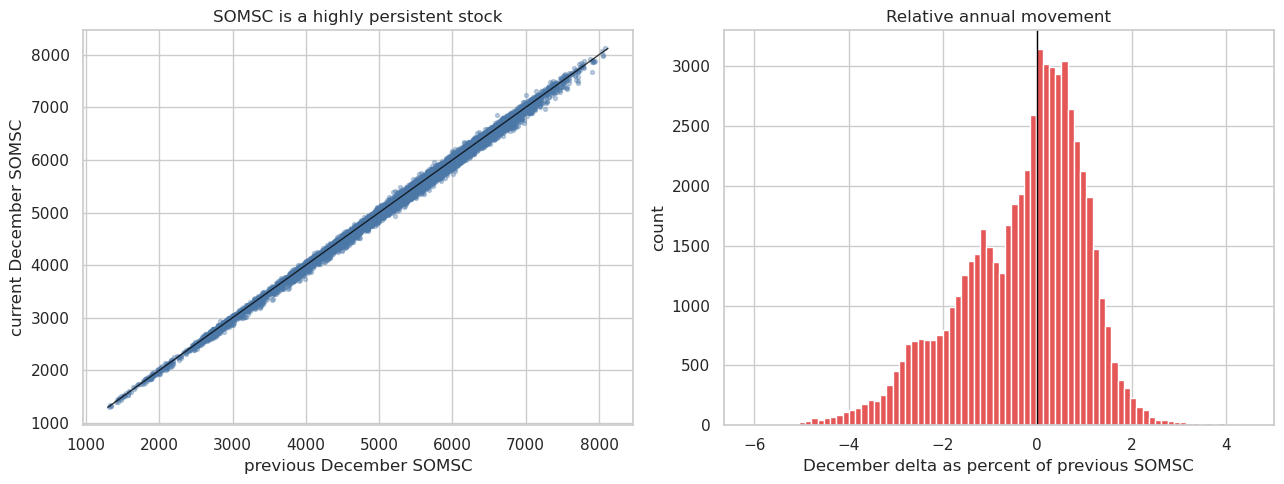

In [16]:
sample = valid.sample(min(len(valid), 8000), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(sample['prev_somsc'], sample['somsc'], s=8, alpha=0.35, color='#4c78a8')
lo = np.nanmin([sample['prev_somsc'].min(), sample['somsc'].min()])
hi = np.nanmax([sample['prev_somsc'].max(), sample['somsc'].max()])
axes[0].plot([lo, hi], [lo, hi], color='black', linewidth=1, alpha=0.75)
axes[0].set_title('SOMSC is a highly persistent stock')
axes[0].set_xlabel('previous December SOMSC')
axes[0].set_ylabel('current December SOMSC')

axes[1].hist(valid['relative_delta_pct'].replace([np.inf, -np.inf], np.nan).dropna(), bins=80, color='#e45756')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Relative annual movement')
axes[1].set_xlabel('December delta as percent of previous SOMSC')
axes[1].set_ylabel('count')
plt.tight_layout()

## One-way variance shares

These are simple one-factor variance shares, not a full mixed model. They are still useful for checking whether SOMSC level and delta are dominated by location, scenario, or year.

,target,factor,one_way_variance_share
6,delta,Year,0.076800
4,delta,point_id,0.061667
5,delta,scenario_id,0.057475
7,delta,split,0.017479
0,somsc,point_id,0.930137
3,somsc,split,0.052031
1,somsc,scenario_id,0.031950
2,somsc,Year,0.009985


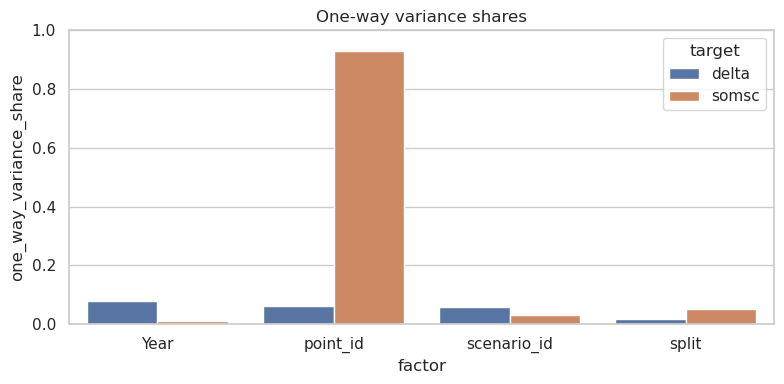

In [17]:
def one_way_variance_share(df, y_col, group_col):
    d = df[[y_col, group_col]].dropna()
    if d.empty:
        return np.nan
    grand = d[y_col].mean()
    total = ((d[y_col] - grand) ** 2).sum()
    if total <= 0:
        return np.nan
    stats = d.groupby(group_col)[y_col].agg(['mean', 'size'])
    between = (stats['size'] * (stats['mean'] - grand) ** 2).sum()
    return float(between / total)

variance_rows = []
for y_col in ['somsc', 'delta']:
    for group_col in ['point_id', 'scenario_id', 'Year', 'split']:
        variance_rows.append({
            'target': y_col,
            'factor': group_col,
            'one_way_variance_share': one_way_variance_share(soc_dec, y_col, group_col),
        })
variance_share = pd.DataFrame(variance_rows).sort_values(['target', 'one_way_variance_share'], ascending=[True, False])
display(variance_share)

if sns is not None:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=variance_share, x='factor', y='one_way_variance_share', hue='target')
    plt.title('One-way variance shares')
    plt.ylim(0, 1)
    plt.tight_layout()

## Save tables for follow-up

In [18]:
tables_to_save = {
    'soc_december_panel': soc_dec,
    'trajectory_summary': trajectory,
    'scenario_summary': scenario_summary.reset_index(),
    'point_sensitivity': point_sensitivity,
    'interesting_points': interesting,
    'driver_correlations': corr_table.reset_index().rename(columns={'index': 'feature'}),
    'driver_rf_importance': importance,
    'baseline_metrics': metrics,
    'variance_share': variance_share,
}

for name, df in tables_to_save.items():
    path = CACHE_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved {name:24s} {df.shape} -> {path}')

Saved soc_december_panel       (62400, 9) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/soc_december_panel.csv
Saved trajectory_summary       (2600, 13) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/trajectory_summary.csv
Saved scenario_summary         (13, 7) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/scenario_summary.csv
Saved point_sensitivity        (200, 12) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/point_sensitivity.csv
Saved interesting_points       (16, 3) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/interesting_points.csv
Saved driver_correlations      (181, 2) -> /projects/standard/kumarv/shared/dwij/daycent/data/analysis_cache/yearly_december_somsc_v1/driver_correlations.csv
Saved driver_rf_importance     (181, 2) -> /projects/stan

## What to look for after running

- If the persistence baseline has extremely high level R2 while delta R2 is weak, the model can look good on absolute SOMSC while learning little about carbon movement.
- If scenario spread is much smaller than point-to-point level differences, scenario effects may be hidden by the location baseline unless the model is trained/evaluated on deltas or scenario contrasts.
- If high-response and low-response points occupy different initial-condition or coordinate regions, a single global LSTM may need stronger static context or point-specific calibration.
- If random forest importance is mostly `prev_somsc`, `Year`, and init/location features, management scenario signal is probably subtle and may need contrastive targets such as scenario deltas relative to a baseline scenario.
- If the test split uses unseen scenarios, unseen points, and future years at once, check the `split` rows separately because that is three extrapolation problems stacked together.